# Notebook 06 — External Candidate Screening and Illustrative Design–Test–Learn Loop

This notebook closes the demonstrative AMP discovery cycle by screening an **external candidate pool** and using model-supported pseudo-feedback to illustrate how an AI-native discovery workflow could be updated after a testing round.

The notebook intentionally distinguishes between:

- **experimental validation**, which is not performed here; and
- **in silico pseudo-feedback**, which is used only to demonstrate the operational logic of a design–test–learn cycle.

Workflow:

1. Load the trained uncertainty-aware ensemble from Notebook 03.
2. Load the interpretable rulebook and scoring scheme from Notebook 05.
3. Import external candidate sequences, preferably from UniProt.
4. Compute the same descriptors used for model training.
5. Predict AMP probability and uncertainty.
6. Apply the rule-aware prioritization score.
7. Define pseudo-feedback labels from high-confidence model-supported decisions.
8. Retrain an illustrative updated ensemble using the original training set plus pseudo-feedback.
9. Compare candidate ranking before and after pseudo-feedback.

In [1]:
# ============================================================
# 1. Imports and configuration
# ============================================================

from __future__ import annotations

import json
import math
import re
import warnings
from datetime import datetime
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# Input artefacts from previous notebooks
TRAINING_DIR = Path("../outputs_training")
RULE_PRIORITY_DIR = Path("../outputs_rule_prioritization")

TRAINING_METADATA_PATH = TRAINING_DIR / "training_metadata.json"
BEST_MODEL_SELECTION_PATH = TRAINING_DIR / "best_model_selection.json"
SPLIT_DATASET_PATH = TRAINING_DIR / "splits" / "amp_model_ready_with_distance_aware_split.csv"
RULEBOOK_PATH = RULE_PRIORITY_DIR / "rules" / "amp_rulebook_from_shap_and_surrogate.csv"
INTERNAL_RANKED_PATH = RULE_PRIORITY_DIR / "tables" / "all_candidates_rule_aware_ranked.csv"

EXTERNAL_FASTA_PATH = Path("../collected_sequences/external_candidates.fasta")

# Local metadata filters applied after download.
# The antimicrobial exclusion avoids trivially rediscovering proteins already annotated
# as antimicrobial in UniProt.
EXCLUDE_UNIPROT_ANTIMICROBIAL_KEYWORD = True

# Signal/secreted filtering can be kept permissive by default because very short bacterial
# proteins may not always carry complete keyword or subcellular metadata.
# Set to True only if the downloaded metadata columns are sufficiently populated.
REQUIRE_SIGNAL_OR_SECRETED_METADATA = False

# Candidate filtering
MIN_LENGTH = 5
MAX_LENGTH = 60
CANONICAL_AA = "ACDEFGHIKLMNPQRSTVWY"
CANONICAL_SET = set(CANONICAL_AA)

# Prioritization weights, matched to Notebook 05
WEIGHT_PROBABILITY = 0.55
WEIGHT_RULE_SCORE = 0.30
WEIGHT_CONFIDENCE = 0.15

# Candidate pool thresholds
HIGH_PROBABILITY_CUTOFF = 0.80
LOW_PROBABILITY_CUTOFF = 0.20
HIGH_RULE_SCORE_CUTOFF = 0.70
LOW_RULE_SCORE_CUTOFF = 0.30

# Pseudo-feedback thresholds
PSEUDO_POSITIVE_PROBABILITY_CUTOFF = 0.85
PSEUDO_NEGATIVE_PROBABILITY_CUTOFF = 0.15
PSEUDO_HIGH_RULE_SCORE_CUTOFF = 0.70
PSEUDO_LOW_RULE_SCORE_CUTOFF = 0.30
MAX_PSEUDO_PER_CLASS = 100
MIN_PSEUDO_PER_CLASS_FOR_UPDATE = 5

# Updated illustrative ensemble
N_UPDATED_CV_SPLITS = 10

# Output directory
OUTPUT_DIR = Path("../outputs_dtl_cycle")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
CANDIDATE_DIR = OUTPUT_DIR / "candidates"

# ============================================================
# Adaptive candidate selection thresholds
# ============================================================

EXPLOITATION_PROBABILITY_QUANTILE = 0.85
EXPLORATION_UNCERTAINTY_QUANTILE = 0.90
RULE_SUPPORT_QUANTILE = 0.75

PSEUDO_POSITIVE_PROBABILITY_QUANTILE = 0.80
PSEUDO_NEGATIVE_PROBABILITY_QUANTILE = 0.20

LOW_UNCERTAINTY_QUANTILE = 0.30
HIGH_UNCERTAINTY_QUANTILE = 0.80

for directory in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, MODEL_DIR, CANDIDATE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {OUTPUT_DIR.resolve()}")
print(f"Run timestamp: {datetime.now().isoformat(timespec='seconds')}")

Output directory: /home/david/Desktop/umag_projects/demonstrative_AMR_peptide_discovery/outputs_dtl_cycle
Run timestamp: 2026-05-23T01:57:01


## 2. Load trained model, metadata, training descriptors, and rulebook

The model ensemble from Notebook 03 provides the predictive component and uncertainty estimate. The rulebook from Notebook 05 provides the interpretable constraints used for rule-aware prioritization.

In [2]:
# ============================================================
# 2. Load required artefacts
# ============================================================

required_paths = [
    TRAINING_METADATA_PATH,
    BEST_MODEL_SELECTION_PATH,
    SPLIT_DATASET_PATH,
    RULEBOOK_PATH,
]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Missing required artefacts. Please run Notebooks 03, 04, and 05 first.\n"
        + "\n".join(missing_paths)
    )

with open(TRAINING_METADATA_PATH, "r") as f:
    training_metadata = json.load(f)

with open(BEST_MODEL_SELECTION_PATH, "r") as f:
    best_model_info = json.load(f)

SEQUENCE_COL = training_metadata.get("sequence_column", "sequence")
LABEL_COL = training_metadata.get("label_column", "label")
DESCRIPTOR_COLS = training_metadata["descriptor_columns"]
BEST_MODEL_NAME = best_model_info["best_model"]

ensemble_model_path = Path(best_model_info["artifacts"]["ensemble_model_path"])
final_model_path = Path(best_model_info["artifacts"]["final_model_path"])

if not ensemble_model_path.exists():
    raise FileNotFoundError(f"CV ensemble model not found: {ensemble_model_path}")

cv_ensemble = joblib.load(ensemble_model_path)
final_model = joblib.load(final_model_path) if final_model_path.exists() else None

training_df = pd.read_csv(SPLIT_DATASET_PATH)
rulebook_df = pd.read_csv(RULEBOOK_PATH)

if INTERNAL_RANKED_PATH.exists():
    internal_ranked_df = pd.read_csv(INTERNAL_RANKED_PATH)
else:
    internal_ranked_df = pd.DataFrame()

print("Best model:", BEST_MODEL_NAME)
print("CV ensemble members:", len(cv_ensemble))
print("Training descriptor table:", training_df.shape)
print("Rulebook:", rulebook_df.shape)
rulebook_df.head()

Best model: extra_trees
CV ensemble members: 10
Training descriptor table: (47175, 46)
Rulebook: (12, 10)


,feature,rule_text,operator,lower_bound,upper_bound,selected_median,interpretable_direction,mean_abs_shap,surrogate_importance,rule_weight
0,AAC_K,AAC_K >= 0.08333,>=,0.083333,NaN,0.222222,higher_values_support_AMP_prediction,0.044008,0.170453,0.265697
1,AAC_M,AAC_M <= 0,<=,NaN,0.000000,0.000000,lower_values_support_AMP_prediction,0.035435,0.133516,0.189400
2,isoelectric_point_approx,isoelectric_point_approx >= 10.84,>=,10.840000,NaN,11.210000,higher_values_support_AMP_prediction,0.032766,0.000000,0.144743
3,positive_fraction,positive_fraction >= 0.2857,>=,0.285714,NaN,0.375000,higher_values_support_AMP_prediction,0.030998,0.460082,0.209145
4,small_fraction,small_fraction <= 0.3333,<=,NaN,0.333333,0.166667,lower_values_support_AMP_prediction,0.020585,0.005720,0.046314


## External FASTA screening scenario

External candidates are loaded directly from a user-provided FASTA file. No online queries or external APIs are used. The remaining workflow (descriptor extraction, prediction, uncertainty estimation, rule-aware ranking, and pseudo-feedback) remains unchanged.


## 3. Candidate acquisition from FASTA

Candidates are loaded directly from a FASTA file. Update `EXTERNAL_FASTA_PATH` if needed.

In [3]:

# ============================================================
# 3. Candidate acquisition from FASTA
# ============================================================

def read_fasta(path: Path) -> pd.DataFrame:
    sequences = []
    headers = []

    header = None
    seq_chunks = []

    with open(path, "r") as handle:
        for line in handle:
            line = line.strip()

            if not line:
                continue

            if line.startswith(">"):
                if header is not None:
                    sequences.append("".join(seq_chunks))
                    headers.append(header)

                header = line[1:]
                seq_chunks = []
            else:
                seq_chunks.append(line)

        if header is not None:
            sequences.append("".join(seq_chunks))
            headers.append(header)

    return pd.DataFrame(
        {
            "candidate_id": headers,
            SEQUENCE_COL: sequences,
        }
    )

if not EXTERNAL_FASTA_PATH.exists():
    raise FileNotFoundError(
        f"External FASTA file not found: {EXTERNAL_FASTA_PATH}"
    )

external_raw_df = read_fasta(EXTERNAL_FASTA_PATH)
candidate_source = str(EXTERNAL_FASTA_PATH)

print("Candidate source:", candidate_source)
print("Raw external candidates:", external_raw_df.shape)

external_raw_df.head()


Candidate source: ../collected_sequences/external_candidates.fasta
Raw external candidates: (16837, 2)


,candidate_id,sequence
0,sp|A0QZ48|PUP_MYCS2 Prokaryotic ubiquitin-like...,MAQEQTKRGGGGGEDDDLPGASAAGQERREKLTEETDDLLDEIDDV...
1,sp|A5A616|MGTS_ECOLI Small protein MgtS OS=Esc...,MLGNMNVFMAVLGIILFSGFLAAYFSHKWDD
2,sp|D3VML5|PZNA_BACVZ Plantazolicin OS=Bacillus...,MTQIKVPTALIASVHGEGQHLFEPMAARCTCTTIISSSSTF
3,sp|E3YBA4|MBCTN_METTR Methanobactin mb-OB3b OS...,MTVKIAQKKVLPVIGRAAALCGSCYPCSCM
4,sp|E5KIB6|CYPA_STRSQ Cypemycin OS=Streptomyces...,MRSEMTLTSTNSAEALAAQDFANTVLSAAAPGFHADCETPAMATPA...


## 4. Candidate cleaning and externality checks

Candidate sequences are filtered using the same basic constraints used during dataset construction: canonical amino acids and compatible peptide length. Sequences already present in the Peptipedia-derived dataset are removed to preserve the external-screening interpretation.

In [4]:
# ============================================================
# 4. Candidate cleaning and local metadata filters
# ============================================================

def clean_sequence(seq: object) -> str:
    if pd.isna(seq):
        return ""
    seq = str(seq).strip().upper()
    seq = re.sub(r"\s+", "", seq)
    seq = seq.replace("*", "")
    return seq


def is_canonical_sequence(seq: str) -> bool:
    return len(seq) > 0 and set(seq).issubset(CANONICAL_SET)


def contains_antimicrobial_annotation(row: pd.Series) -> bool:
    """Detect explicit antimicrobial annotation in available UniProt metadata."""
    metadata_fields = [
        "keywords",
        "protein_name",
        "subcellular_location",
    ]
    text = " ".join(
        str(row.get(col, ""))
        for col in metadata_fields
        if col in row.index and not pd.isna(row.get(col, ""))
    )
    return bool(re.search(r"antimicrobial|antibiotic|defensin|bacteriocin", text, flags=re.IGNORECASE))


def has_signal_or_secreted_metadata(row: pd.Series) -> bool:
    """Detect signal/secreted-like metadata when available."""
    metadata_fields = [
        "keywords",
        "protein_name",
        "subcellular_location",
    ]
    text = " ".join(
        str(row.get(col, ""))
        for col in metadata_fields
        if col in row.index and not pd.isna(row.get(col, ""))
    )
    return bool(re.search(r"signal|secreted|secretion|extracellular", text, flags=re.IGNORECASE))


external_df = external_raw_df.copy()

if SEQUENCE_COL not in external_df.columns:
    raise ValueError(
        f"Expected a standardized sequence column named '{SEQUENCE_COL}', "
        f"but available columns are: {list(external_df.columns)}"
    )

external_df[SEQUENCE_COL] = external_df[SEQUENCE_COL].apply(clean_sequence)
external_df["length"] = external_df[SEQUENCE_COL].str.len()
external_df["is_canonical"] = external_df[SEQUENCE_COL].apply(is_canonical_sequence)

initial_n = len(external_df)

external_df = external_df.drop_duplicates(subset=SEQUENCE_COL).copy()
after_dedup_n = len(external_df)

external_df = external_df[
    external_df["is_canonical"]
    & external_df["length"].between(MIN_LENGTH, MAX_LENGTH)
].copy()
after_canonical_length_n = len(external_df)

if EXCLUDE_UNIPROT_ANTIMICROBIAL_KEYWORD:
    external_df["has_explicit_antimicrobial_annotation"] = external_df.apply(
        contains_antimicrobial_annotation,
        axis=1,
    )
    external_df = external_df[
        ~external_df["has_explicit_antimicrobial_annotation"]
    ].copy()
after_antimicrobial_exclusion_n = len(external_df)

if REQUIRE_SIGNAL_OR_SECRETED_METADATA:
    external_df["has_signal_or_secreted_metadata"] = external_df.apply(
        has_signal_or_secreted_metadata,
        axis=1,
    )
    external_df = external_df[
        external_df["has_signal_or_secreted_metadata"]
    ].copy()
after_signal_filter_n = len(external_df)

known_sequences = set(training_df[SEQUENCE_COL].astype(str).str.upper())
external_df["present_in_training_dataset"] = external_df[SEQUENCE_COL].isin(known_sequences)
external_df = external_df[~external_df["present_in_training_dataset"]].copy()
after_externality_n = len(external_df)

external_df = external_df.reset_index(drop=True)
external_df["candidate_id"] = external_df["candidate_id"].astype(str)

cleaning_summary = pd.DataFrame({
    "stage": [
        "raw_uniprot_candidates",
        "after_sequence_deduplication",
        "after_canonical_and_length_filtering",
        "after_excluding_explicit_antimicrobial_annotations",
        "after_optional_signal_or_secreted_filter",
        "after_removing_training_sequences",
    ],
    "n_candidates": [
        initial_n,
        after_dedup_n,
        after_canonical_length_n,
        after_antimicrobial_exclusion_n,
        after_signal_filter_n,
        after_externality_n,
    ],
})

cleaned_candidates_path = CANDIDATE_DIR / "external_candidates_cleaned.csv"
cleaning_summary_path = TABLE_DIR / "external_candidate_cleaning_summary.csv"
external_df.to_csv(cleaned_candidates_path, index=False)
cleaning_summary.to_csv(cleaning_summary_path, index=False)

print("Saved:", cleaned_candidates_path)
print("Saved:", cleaning_summary_path)
cleaning_summary


Saved: ../outputs_dtl_cycle/candidates/external_candidates_cleaned.csv
Saved: ../outputs_dtl_cycle/tables/external_candidate_cleaning_summary.csv


,stage,n_candidates
0,raw_uniprot_candidates,16837
1,after_sequence_deduplication,10785
2,after_canonical_and_length_filtering,4047
3,after_excluding_explicit_antimicrobial_annotat...,4047
4,after_optional_signal_or_secreted_filter,4047
5,after_removing_training_sequences,3890


## 5. Descriptor computation for external candidates

The same descriptor definitions used in Notebook 02 are applied here to guarantee compatibility with the trained model.

In [5]:
# ============================================================
# 5. Descriptor functions
# ============================================================

AA_MASS = {
    "A": 89.09, "C": 121.16, "D": 133.10, "E": 147.13, "F": 165.19,
    "G": 75.07, "H": 155.16, "I": 131.17, "K": 146.19, "L": 131.17,
    "M": 149.21, "N": 132.12, "P": 115.13, "Q": 146.15, "R": 174.20,
    "S": 105.09, "T": 119.12, "V": 117.15, "W": 204.23, "Y": 181.19,
}

KD_HYDROPATHY = {
    "A": 1.8, "C": 2.5, "D": -3.5, "E": -3.5, "F": 2.8,
    "G": -0.4, "H": -3.2, "I": 4.5, "K": -3.9, "L": 3.8,
    "M": 1.9, "N": -3.5, "P": -1.6, "Q": -3.5, "R": -4.5,
    "S": -0.8, "T": -0.7, "V": 4.2, "W": -0.9, "Y": -1.3,
}

DESTABILIZING_RESIDUES = set("DEKRNQPS")
HYDROPHOBIC_AA = set("AILMFWYV")
AROMATIC_AA = set("FWY")
POSITIVE_AA = set("KRH")
NEGATIVE_AA = set("DE")
POLAR_AA = set("STNQCY")
SMALL_AA = set("AGSTCPDNV")

HELIX_PROPENSITY = {
    "A": 1.45, "C": 0.77, "D": 0.98, "E": 1.53, "F": 1.12,
    "G": 0.53, "H": 1.24, "I": 1.00, "K": 1.07, "L": 1.34,
    "M": 1.20, "N": 0.73, "P": 0.59, "Q": 1.17, "R": 0.79,
    "S": 0.79, "T": 0.82, "V": 1.14, "W": 1.14, "Y": 0.61,
}

SHEET_PROPENSITY = {
    "A": 0.97, "C": 1.30, "D": 0.80, "E": 0.26, "F": 1.28,
    "G": 0.81, "H": 0.71, "I": 1.60, "K": 0.74, "L": 1.22,
    "M": 1.67, "N": 0.65, "P": 0.62, "Q": 1.23, "R": 0.90,
    "S": 0.72, "T": 1.20, "V": 1.65, "W": 1.19, "Y": 1.29,
}

TURN_PROPENSITY = {
    "A": 0.66, "C": 1.19, "D": 1.46, "E": 0.74, "F": 0.60,
    "G": 1.56, "H": 0.95, "I": 0.47, "K": 1.01, "L": 0.59,
    "M": 0.60, "N": 1.56, "P": 1.52, "Q": 0.98, "R": 0.95,
    "S": 1.43, "T": 0.96, "V": 0.50, "W": 0.96, "Y": 1.14,
}

PKA = {
    "N_TERM": 9.69,
    "C_TERM": 2.34,
    "K": 10.5,
    "R": 12.5,
    "H": 6.0,
    "D": 3.9,
    "E": 4.1,
    "C": 8.3,
    "Y": 10.1,
}


def amino_acid_composition(seq: str) -> Dict[str, float]:
    n = len(seq)
    if n == 0:
        return {f"AAC_{aa}": np.nan for aa in CANONICAL_AA}
    return {f"AAC_{aa}": seq.count(aa) / n for aa in CANONICAL_AA}


def sequence_entropy(seq: str, normalized: bool = False) -> float:
    n = len(seq)
    if n == 0:
        return np.nan
    counts = np.array([seq.count(aa) for aa in CANONICAL_AA], dtype=float)
    probs = counts[counts > 0] / n
    h = -np.sum(probs * np.log2(probs))
    if normalized:
        return h / np.log2(len(CANONICAL_AA))
    return h


def fraction_of(seq: str, aa_set: set[str]) -> float:
    n = len(seq)
    if n == 0:
        return np.nan
    return sum(1 for aa in seq if aa in aa_set) / n


def molecular_weight(seq: str) -> float:
    if len(seq) == 0:
        return np.nan
    return sum(AA_MASS.get(aa, 0.0) for aa in seq) - (len(seq) - 1) * 18.015


def gravy(seq: str) -> float:
    if len(seq) == 0:
        return np.nan
    return float(np.mean([KD_HYDROPATHY[aa] for aa in seq]))


def aliphatic_index(seq: str) -> float:
    n = len(seq)
    if n == 0:
        return np.nan
    x_a = seq.count("A") / n * 100
    x_v = seq.count("V") / n * 100
    x_i = seq.count("I") / n * 100
    x_l = seq.count("L") / n * 100
    return x_a + 2.9 * x_v + 3.9 * (x_i + x_l)


def instability_proxy(seq: str) -> float:
    return 100 * fraction_of(seq, DESTABILIZING_RESIDUES)


def net_charge(seq: str, ph: float = 7.4) -> float:
    charge = 0.0
    charge += 1 / (1 + 10 ** (ph - PKA["N_TERM"]))
    charge -= 1 / (1 + 10 ** (PKA["C_TERM"] - ph))
    for aa in seq:
        if aa in ["K", "R", "H"]:
            charge += 1 / (1 + 10 ** (ph - PKA[aa]))
        elif aa in ["D", "E", "C", "Y"]:
            charge -= 1 / (1 + 10 ** (PKA[aa] - ph))
    return charge


def approximate_pI(seq: str) -> float:
    if len(seq) == 0:
        return np.nan
    ph_grid = np.linspace(2.0, 12.0, 1001)
    charges = np.array([net_charge(seq, ph=ph) for ph in ph_grid])
    return float(ph_grid[np.argmin(np.abs(charges))])


def avg_propensity(seq: str, scale: Dict[str, float]) -> float:
    if len(seq) == 0:
        return np.nan
    return float(np.mean([scale[aa] for aa in seq]))


def descriptor_dict(seq: str) -> Dict[str, float]:
    desc = {
        "length": len(seq),
        "molecular_weight": molecular_weight(seq),
        "shannon_entropy": sequence_entropy(seq, normalized=False),
        "normalized_entropy": sequence_entropy(seq, normalized=True),
        "unique_residue_fraction": len(set(seq)) / len(seq) if len(seq) > 0 else np.nan,
        "net_charge_pH_7_4": net_charge(seq, ph=7.4),
        "absolute_charge_pH_7_4": abs(net_charge(seq, ph=7.4)),
        "isoelectric_point_approx": approximate_pI(seq),
        "positive_fraction": fraction_of(seq, POSITIVE_AA),
        "negative_fraction": fraction_of(seq, NEGATIVE_AA),
        "charged_fraction": fraction_of(seq, POSITIVE_AA | NEGATIVE_AA),
        "hydrophobic_fraction": fraction_of(seq, HYDROPHOBIC_AA),
        "polar_fraction": fraction_of(seq, POLAR_AA),
        "aromatic_fraction": fraction_of(seq, AROMATIC_AA),
        "small_fraction": fraction_of(seq, SMALL_AA),
        "gravy": gravy(seq),
        "aliphatic_index": aliphatic_index(seq),
        "instability_proxy": instability_proxy(seq),
        "helix_propensity": avg_propensity(seq, HELIX_PROPENSITY),
        "sheet_propensity": avg_propensity(seq, SHEET_PROPENSITY),
        "turn_propensity": avg_propensity(seq, TURN_PROPENSITY),
    }
    desc.update(amino_acid_composition(seq))
    return desc

In [6]:
# ============================================================
# 6. Compute descriptors for external candidates
# ============================================================

if external_df.empty:
    raise ValueError("No external candidates remain after filtering.")

feature_records = [descriptor_dict(seq) for seq in external_df[SEQUENCE_COL].tolist()]
external_features_df = pd.DataFrame(feature_records)

for col in DESCRIPTOR_COLS:
    if col not in external_features_df.columns:
        external_features_df[col] = np.nan

external_model_df = pd.concat(
    [external_df.reset_index(drop=True), external_features_df.reset_index(drop=True)],
    axis=1,
)

external_descriptor_path = TABLE_DIR / "external_candidates_with_descriptors.csv"
external_model_df.to_csv(external_descriptor_path, index=False)

print("Saved:", external_descriptor_path)
print("External descriptor table:", external_model_df.shape)
external_model_df[["candidate_id", SEQUENCE_COL, "length"] + DESCRIPTOR_COLS[:5]].head()

Saved: ../outputs_dtl_cycle/tables/external_candidates_with_descriptors.csv
External descriptor table: (3890, 47)


,candidate_id,sequence,length,length,length,length,shannon_entropy,normalized_entropy,unique_residue_fraction,net_charge_pH_7_4
0,sp|A5A616|MGTS_ECOLI Small protein MgtS OS=Esc...,MLGNMNVFMAVLGIILFSGFLAAYFSHKWDD,31,31,31,31,3.655336,0.845765,0.451613,-0.968960
1,sp|O07623|SBOA_BACSU Subtilosin-A OS=Bacillus ...,MKKAVIVENKGCATCSIGAACLVDGPIPDFEIAGATGLFGLWG,43,43,43,43,3.747641,0.867123,0.372093,-1.341288
2,sp|O54329|LANA_STRMG Lantibiotic mutacin-2 OS=...,MNKLNSNAVVSLNEVSDSELDTILGGNRWWQGVVPTVSYECRMNSW...,53,53,53,53,4.021402,0.930465,0.377358,-2.302920
3,sp|P09191|PSBF_SYNY3 Cytochrome b559 subunit b...,MATQNPNQPVTYPIFTVRWLAVHTLAVPSVFFVGAIAAMQFIQR,44,44,44,44,3.737285,0.864726,0.363636,2.031186
4,sp|P0A3W4|VIRB7_AGRTU Type IV secretion system...,MKYCLLCLVVALSGCQTNDTIASCKGPIFPLNVGRWQPTPSDLQLR...,55,55,55,55,3.991442,0.923533,0.327273,1.542998


## 6. External novelty diagnostics

To support the external-screening interpretation, each candidate is assigned a nearest-neighbour distance to the training set in the same standardized descriptor space.

In [7]:
# ============================================================
# 7. Distance to training set in descriptor space
# ============================================================

train_reference_df = training_df[training_df.get("split", "train").eq("train")].copy()
if train_reference_df.empty:
    train_reference_df = training_df.copy()

X_train_reference = train_reference_df[DESCRIPTOR_COLS].replace([np.inf, -np.inf], np.nan)

# Ensure no duplicated descriptor columns exist before alignment
if external_model_df.columns.duplicated().any():
    duplicated_cols = sorted(set(external_model_df.columns[external_model_df.columns.duplicated()]))
    print(f"Removing duplicated columns: {duplicated_cols}")
    external_model_df = external_model_df.loc[:, ~external_model_df.columns.duplicated()]

missing_features = sorted(set(DESCRIPTOR_COLS) - set(external_model_df.columns))
if missing_features:
    raise ValueError(
        f"Missing descriptor columns in external dataset: {missing_features}"
    )


X_external = external_model_df.reindex(columns=DESCRIPTOR_COLS)
X_external = X_external.replace([np.inf, -np.inf], np.nan)

missing_features = sorted(set(DESCRIPTOR_COLS) - set(external_model_df.columns))
if missing_features:
    raise ValueError(
        f"Missing descriptor columns in external dataset: {missing_features}"
    )

# enforce exact training feature order from training_metadata.json
X_external = X_external[DESCRIPTOR_COLS]

imputer_for_distance = SimpleImputer(strategy="median")
scaler_for_distance = StandardScaler()

X_train_reference_imp = imputer_for_distance.fit_transform(X_train_reference)
X_train_reference_scaled = scaler_for_distance.fit_transform(X_train_reference_imp)
X_external_scaled = scaler_for_distance.transform(imputer_for_distance.transform(X_external))

nn = NearestNeighbors(n_neighbors=1, metric="euclidean")
nn.fit(X_train_reference_scaled)
nearest_distance, nearest_index = nn.kneighbors(X_external_scaled)

external_model_df["nearest_train_distance"] = nearest_distance.ravel()
external_model_df["nearest_train_sequence"] = train_reference_df.iloc[nearest_index.ravel()][SEQUENCE_COL].to_numpy()
external_model_df["nearest_train_label"] = train_reference_df.iloc[nearest_index.ravel()][LABEL_COL].to_numpy() if LABEL_COL in train_reference_df.columns else np.nan

novelty_summary = external_model_df["nearest_train_distance"].describe().to_frame(name="nearest_train_distance")
novelty_summary_path = TABLE_DIR / "external_candidate_nearest_train_distance_summary.csv"
novelty_summary.to_csv(novelty_summary_path)

print("Saved:", novelty_summary_path)
novelty_summary

Removing duplicated columns: ['length']
Saved: ../outputs_dtl_cycle/tables/external_candidate_nearest_train_distance_summary.csv


,nearest_train_distance
count,3890.000000
mean,2.223267
std,0.689507
min,0.000000
25%,1.824031
50%,2.206755
75%,2.562667
max,6.786183


## 7. Predict AMP probability and uncertainty

The uncertainty estimate is computed as the standard deviation of positive-class probabilities across the cross-validation ensemble members from Notebook 03.

In [8]:
# ============================================================
# 8. Ensemble prediction and uncertainty
# ============================================================

def ensemble_predict_proba(models: List[object], X: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return mean probability, uncertainty, and member probabilities."""
    probs = np.column_stack([model.predict_proba(X)[:, 1] for model in models])
    mean_prob = probs.mean(axis=1)
    uncertainty = probs.std(axis=1)
    return mean_prob, uncertainty, probs

X_external_model = external_model_df[DESCRIPTOR_COLS].copy()
external_prob, external_uncertainty, external_member_probs = ensemble_predict_proba(cv_ensemble, X_external_model)

external_model_df["probability_amp_ensemble"] = external_prob
external_model_df["uncertainty_std"] = external_uncertainty
external_model_df["prediction"] = (external_model_df["probability_amp_ensemble"] >= 0.5).astype(int)

member_prob_df = pd.DataFrame(
    external_member_probs,
    columns=[f"ensemble_member_{i+1:02d}_probability_amp" for i in range(external_member_probs.shape[1])],
)
member_prob_path = TABLE_DIR / "external_candidate_ensemble_member_probabilities.csv"
member_prob_df.insert(0, "candidate_id", external_model_df["candidate_id"].values)
member_prob_df.to_csv(member_prob_path, index=False)

print("Saved:", member_prob_path)
external_model_df[["candidate_id", SEQUENCE_COL, "probability_amp_ensemble", "uncertainty_std", "prediction"]].head()

Saved: ../outputs_dtl_cycle/tables/external_candidate_ensemble_member_probabilities.csv


,candidate_id,sequence,probability_amp_ensemble,uncertainty_std,prediction
0,sp|A5A616|MGTS_ECOLI Small protein MgtS OS=Esc...,MLGNMNVFMAVLGIILFSGFLAAYFSHKWDD,0.1966,0.019433,0
1,sp|O07623|SBOA_BACSU Subtilosin-A OS=Bacillus ...,MKKAVIVENKGCATCSIGAACLVDGPIPDFEIAGATGLFGLWG,0.5302,0.022422,1
2,sp|O54329|LANA_STRMG Lantibiotic mutacin-2 OS=...,MNKLNSNAVVSLNEVSDSELDTILGGNRWWQGVVPTVSYECRMNSW...,0.4158,0.034565,0
3,sp|P09191|PSBF_SYNY3 Cytochrome b559 subunit b...,MATQNPNQPVTYPIFTVRWLAVHTLAVPSVFFVGAIAAMQFIQR,0.2630,0.016474,0
4,sp|P0A3W4|VIRB7_AGRTU Type IV secretion system...,MKYCLLCLVVALSGCQTNDTIASCKGPIFPLNVGRWQPTPSDLQLR...,0.4250,0.022077,0


## 8. Apply interpretable rulebook and rule-aware priority score

The same scoring logic from Notebook 05 is applied to external candidates, preserving a transparent decision rule:

\[
S = 0.55 P(AMP) + 0.30 S_{rule} + 0.15 S_{confidence}
\]

where confidence is derived from normalized ensemble uncertainty.

In [9]:
# ============================================================
# 9. Rule evaluation and rule-aware prioritization
# ============================================================

def evaluate_rule(values: pd.Series, operator: str, lower: float, upper: float) -> pd.Series:
    values = pd.to_numeric(values, errors="coerce")
    if operator == ">=":
        return values.ge(lower).fillna(False).astype(int)
    if operator == "<=":
        return values.le(upper).fillna(False).astype(int)
    if operator == "between":
        return (values.ge(lower) & values.le(upper)).fillna(False).astype(int)
    raise ValueError(f"Unsupported operator: {operator}")


def evaluate_rule_soft(values: pd.Series, operator: str, lower: float, upper: float) -> pd.Series:
    x = pd.to_numeric(values, errors="coerce")
    finite = np.isfinite(x)
    if finite.sum() == 0:
        return pd.Series(np.zeros(len(x)), index=x.index)

    xmin = float(np.nanpercentile(x[finite], 1))
    xmax = float(np.nanpercentile(x[finite], 99))
    span = max(xmax - xmin, 1e-8)

    if operator == ">=":
        score = (x - lower) / span + 0.5
    elif operator == "<=":
        score = (upper - x) / span + 0.5
    elif operator == "between":
        center = (lower + upper) / 2.0
        half_width = max((upper - lower) / 2.0, 1e-8)
        score = 1.0 - (np.abs(x - center) / (2.0 * half_width))
    else:
        raise ValueError(f"Unsupported operator: {operator}")

    return score.clip(0.0, 1.0).fillna(0.0)


def apply_rulebook(df: pd.DataFrame, rulebook: pd.DataFrame) -> Tuple[pd.DataFrame, List[str], List[str]]:
    df = df.copy()
    rule_binary_cols = []
    rule_soft_cols = []
    effective_rule_rows = []

    for rule_id, row in rulebook.reset_index(drop=True).iterrows():
        feature = row["feature"]
        if feature not in df.columns:
            print(f"Skipping rule because feature is missing: {feature}")
            continue

        binary_col = f"rule_{rule_id + 1:02d}__{feature}__binary"
        soft_col = f"rule_{rule_id + 1:02d}__{feature}__soft"

        df[binary_col] = evaluate_rule(
            df[feature],
            operator=row["operator"],
            lower=row["lower_bound"],
            upper=row["upper_bound"],
        )
        df[soft_col] = evaluate_rule_soft(
            df[feature],
            operator=row["operator"],
            lower=row["lower_bound"],
            upper=row["upper_bound"],
        )

        rule_binary_cols.append(binary_col)
        rule_soft_cols.append(soft_col)
        effective_rule_rows.append(row)

    if not rule_binary_cols:
        raise ValueError("No rule could be evaluated on the external candidate descriptor table.")

    effective_rulebook = pd.DataFrame(effective_rule_rows)
    rule_weights = effective_rulebook["rule_weight"].to_numpy(dtype=float)
    rule_weights = rule_weights / rule_weights.sum()

    df["n_rules_satisfied"] = df[rule_binary_cols].sum(axis=1)
    df["n_rules_total"] = len(rule_binary_cols)
    df["binary_rule_score"] = df["n_rules_satisfied"] / df["n_rules_total"]
    df["weighted_rule_score"] = df[rule_binary_cols].to_numpy(dtype=float).dot(rule_weights)
    df["soft_rule_score"] = df[rule_soft_cols].to_numpy(dtype=float).dot(rule_weights)

    return df, rule_binary_cols, rule_soft_cols


external_scored_df, rule_binary_cols, rule_soft_cols = apply_rulebook(external_model_df, rulebook_df)

# Use internal uncertainty distribution as reference when available; otherwise use external p95.
if not internal_ranked_df.empty and "uncertainty_std" in internal_ranked_df.columns:
    uncertainty_scale = float(np.nanpercentile(internal_ranked_df["uncertainty_std"], 95))
else:
    uncertainty_scale = float(np.nanpercentile(external_scored_df["uncertainty_std"], 95))

if uncertainty_scale <= 0 or np.isnan(uncertainty_scale):
    uncertainty_scale = 1.0

external_scored_df["uncertainty_risk"] = (external_scored_df["uncertainty_std"] / uncertainty_scale).clip(0.0, 1.0)
external_scored_df["confidence_score"] = 1.0 - external_scored_df["uncertainty_risk"]
external_scored_df["rule_aware_priority_score"] = (
    WEIGHT_PROBABILITY * external_scored_df["probability_amp_ensemble"]
    + WEIGHT_RULE_SCORE * external_scored_df["soft_rule_score"]
    + WEIGHT_CONFIDENCE * external_scored_df["confidence_score"]
).clip(0.0, 1.0)

external_ranked_df = external_scored_df.sort_values("rule_aware_priority_score", ascending=False).reset_index(drop=True)
external_ranked_df["priority_rank"] = np.arange(1, len(external_ranked_df) + 1)

external_ranked_path = TABLE_DIR / "external_candidates_rule_aware_ranked_pre_feedback.csv"
external_ranked_df.to_csv(external_ranked_path, index=False)

print("Saved:", external_ranked_path)
external_ranked_df[[
    "priority_rank", "candidate_id", SEQUENCE_COL, "probability_amp_ensemble", "uncertainty_std",
    "soft_rule_score", "rule_aware_priority_score", "nearest_train_distance"
]].head(20)

Saved: ../outputs_dtl_cycle/tables/external_candidates_rule_aware_ranked_pre_feedback.csv


,priority_rank,candidate_id,sequence,probability_amp_ensemble,uncertainty_std,soft_rule_score,rule_aware_priority_score,nearest_train_distance
0,1,sp|A1QZM6|RL34_BORT9 Large ribosomal subunit p...,MKRTYQPSRVKRNRKFGFRARMKTKGGRLILARRRAKGRSKLTVSD...,0.9632,0.031038,0.642630,0.849592,5.673495e-01
1,2,sp|B1HPM8|RL34_LYSSC Large ribosomal subunit p...,MKRTYQPKKRKHSKVHGFRARMSTKNGRKVLAARRRKGRKVLSA,0.9230,0.013631,0.656253,0.844444,1.323087e+00
2,3,sp|Q0SN69|RL34_BORAP Large ribosomal subunit p...,MKRTYQPSRVKRNRKFGFRARMKTKGGRLILSRRRAKGRIKLTVSD...,0.9582,0.036937,0.645217,0.843255,5.971124e-01
3,4,sp|A4ITX5|RL34_GEOTN Large ribosomal subunit p...,MKRTYQPNKRKRSKVHGFRARMSTKNGRKVLARRRRKGRKVLSA,0.9664,0.041587,0.631153,0.840107,3.261923e-01
4,5,sp|B5RLZ7|RL34_BORDL Large ribosomal subunit p...,MKRTYQPSRVKRNRKFGFRARMKTKSGRLILARRRAKGRSKLTVSD...,0.9348,0.022613,0.637748,0.838739,7.052127e-01
5,6,sp|B2S0E3|RL34_BORHD Large ribosomal subunit p...,MKRTYQPSRVKRNRKFGFRARMKTKGGRLILARRRAKGRSKLTVSD...,0.9444,0.026454,0.622542,0.836616,6.210073e-01
6,7,sp|A6QKK4|RL34_STAAE Large ribosomal subunit p...,MVKRTYQPNKRKHSKVHGFRKRMSTKNGRKVLARRRRKGRKVLSA,0.9160,0.020938,0.659143,0.836056,9.379823e-01
7,8,sp|B9KFQ2|RL34_CAMLR Large ribosomal subunit p...,MKRTYQPHKTPKKRTHGFRVRMKSKNGRKVINARRAKGRKRLAV,0.9162,0.023536,0.663512,0.835555,1.408031e+00
8,9,sp|C5D9Z2|RL34_GEOSW Large ribosomal subunit p...,MKRTYQPNKRKRSKVHGFRARMSTRNGRKVLARRRRKGRKVLSA,0.9806,0.058200,0.607868,0.828643,2.920019e-07
9,10,sp|A7ZCY6|RL34_CAMC1 Large ribosomal subunit p...,MKRTYQPHKTPKKRTHGFRLRMKTKNGRKVINARRAKGRKRLAA,0.8766,0.008720,0.670778,0.826914,1.673217e+00


## 9. Candidate pool assignment

Candidates are partitioned into practical decision pools:

- **exploitation candidates**: high probability, low uncertainty, and strong rule support;
- **exploration candidates**: promising but uncertain candidates that may be informative for learning;
- **low-priority candidates**: weak probability and weak rule support;
- **standard-priority candidates**: all other cases.

In [10]:
# ============================================================
# 10. Assign external candidate pools
# ============================================================

prob = external_ranked_df["probability_amp_ensemble"]
unc = external_ranked_df["uncertainty_std"]
rule = external_ranked_df["soft_rule_score"]

high_prob_cutoff = prob.quantile(
    EXPLOITATION_PROBABILITY_QUANTILE
)

high_rule_cutoff = rule.quantile(
    RULE_SUPPORT_QUANTILE
)

low_unc_cutoff = unc.quantile(
    LOW_UNCERTAINTY_QUANTILE
)

high_unc_cutoff = unc.quantile(
    HIGH_UNCERTAINTY_QUANTILE
)

external_ranked_df["candidate_pool"] = "standard_priority"

# Exploitation
external_ranked_df.loc[
    (
        prob >= high_prob_cutoff
    )
    &
    (
        unc <= low_unc_cutoff
    )
    &
    (
        rule >= high_rule_cutoff
    ),
    "candidate_pool"
] = "exploitation"

# Exploration
external_ranked_df.loc[
    (
        unc >= high_unc_cutoff
    )
    &
    (
        prob >= 0.50
    ),
    "candidate_pool"
] = "exploration"

# Rule-supported
external_ranked_df.loc[
    (
        rule >= high_rule_cutoff
    )
    &
    (
        prob >= 0.50
    ),
    "candidate_pool"
] = "rule_supported"

external_ranked_df["candidate_pool"].value_counts()

candidate_pool
standard_priority    2683
rule_supported        947
exploration           260
Name: count, dtype: int64

## 10. Define in silico pseudo-feedback labels

Pseudo-feedback labels are **not experimental labels**. They are model-supported labels used only to demonstrate how a design–test–learn loop could ingest new feedback after a testing round.

High-confidence pseudo-positive candidates satisfy:

- high predicted AMP probability;
- low uncertainty;
- high rule support.

High-confidence pseudo-negative candidates satisfy:

- low predicted AMP probability;
- low uncertainty;
- low rule support.

In [11]:
# ============================================================
# 11. Pseudo-feedback label construction
# ============================================================

positive_prob_cutoff = prob.quantile(PSEUDO_POSITIVE_PROBABILITY_QUANTILE)
negative_prob_cutoff = prob.quantile(PSEUDO_NEGATIVE_PROBABILITY_QUANTILE)
rule_cutoff = rule.quantile(RULE_SUPPORT_QUANTILE)
low_unc_cutoff = unc.quantile(LOW_UNCERTAINTY_QUANTILE)

pseudo_positive_mask = (
    (prob >= positive_prob_cutoff)
    & (unc <= low_unc_cutoff)
    & (rule >= rule_cutoff)
)

pseudo_negative_mask = (
    (prob <= negative_prob_cutoff)
    & (unc <= low_unc_cutoff)
)

pseudo_positive_df = external_ranked_df.loc[pseudo_positive_mask].copy()
pseudo_positive_df["pseudo_feedback_label"] = 1

pseudo_negative_df = external_ranked_df.loc[pseudo_negative_mask].copy()
pseudo_negative_df["pseudo_feedback_label"] = 0

pseudo_feedback_df = pd.concat(
    [pseudo_positive_df, pseudo_negative_df],
    axis=0,
    ignore_index=True,
)

print(f"Pseudo positives: {len(pseudo_positive_df)}")
print(f"Pseudo negatives: {len(pseudo_negative_df)}")
print(f"Total pseudo-feedback examples: {len(pseudo_feedback_df)}")

pseudo_feedback_df.head()


Pseudo positives: 173
Pseudo negatives: 433
Total pseudo-feedback examples: 606


,candidate_id,sequence,length,is_canonical,has_explicit_antimicrobial_annotation,present_in_training_dataset,molecular_weight,shannon_entropy,normalized_entropy,unique_residue_fraction,...,n_rules_total,binary_rule_score,weighted_rule_score,soft_rule_score,uncertainty_risk,confidence_score,rule_aware_priority_score,priority_rank,candidate_pool,pseudo_feedback_label
0,sp|B1HPM8|RL34_LYSSC Large ribosomal subunit p...,MKRTYQPKKRKHSKVHGFRARMSTKNGRKVLAARRRKGRKVLSA,44,True,False,False,5206.255,3.474811,0.803996,0.340909,...,12,0.666667,0.703967,0.656253,0.067213,0.932787,0.844444,2,rule_supported,1
1,sp|A7ZCY6|RL34_CAMC1 Large ribosomal subunit p...,MKRTYQPHKTPKKRTHGFRLRMKTKNGRKVINARRAKGRKRLAA,44,True,False,False,5273.345,3.463669,0.801418,0.340909,...,12,0.750000,0.732875,0.670778,0.042998,0.957002,0.826914,10,rule_supported,1
2,sp|Q6KH13|RL34_MYCM1 Large ribosomal subunit p...,MKRTYQPKKRKHAKTHGFRSRMATKNGRKVLKLRRLKGRYQLTVSDK,47,True,False,False,5684.800,3.597692,0.832427,0.340426,...,12,0.666667,0.703967,0.660474,0.090649,0.909351,0.826135,11,rule_supported,1
3,sp|A0Q422|RL34_FRATN Large ribosomal subunit p...,MKRTFQPSNLKRKRTHGFRARMKTLSGRKVIRNRRAKGRAKLAA,44,True,False,False,5180.195,3.487953,0.807036,0.340909,...,12,0.666667,0.703967,0.592268,0.079784,0.920216,0.825563,12,rule_supported,1
4,sp|B5FEU9|RL34_ALIFM Large ribosomal subunit p...,MKRTFQPSVLKRKRSHGFRARMATKNGRNVINARRAKGRKRLSK,44,True,False,False,5195.175,3.524536,0.815501,0.340909,...,12,0.666667,0.703967,0.584391,0.072127,0.927873,0.825008,13,rule_supported,1


## 11. Illustrative model update with pseudo-feedback

This section retrains the same model family using the original training partition plus pseudo-feedback candidates. This is only an **operational demonstration** of model updating. It should not be interpreted as evidence of biological improvement.

In [12]:
# ============================================================
# 12. Retrain illustrative updated ensemble with pseudo-feedback
# ============================================================

def fit_updated_cv_ensemble(
    base_pipeline: object,
    X: pd.DataFrame,
    y: np.ndarray,
    n_splits: int = 10,
    random_state: int = 42,
) -> List[object]:
    """Fit a CV ensemble by cloning the supplied baseline pipeline."""
    min_class_count = int(pd.Series(y).value_counts().min())
    effective_splits = max(2, min(n_splits, min_class_count))

    cv = StratifiedKFold(
        n_splits=effective_splits,
        shuffle=True,
        random_state=random_state,
    )

    models = []
    for fold, (fit_idx, _) in enumerate(cv.split(X, y), start=1):
        model = clone(base_pipeline)
        model.fit(X.iloc[fit_idx], y[fit_idx])
        models.append(model)
        print(f"Updated pseudo-feedback fold {fold:02d}/{effective_splits} fitted")
    return models


has_enough_pseudo = False
if not pseudo_feedback_df.empty:
    pseudo_counts = pseudo_feedback_df["pseudo_feedback_label"].value_counts()
    has_enough_pseudo = all(
        pseudo_counts.get(cls, 0) >= MIN_PSEUDO_PER_CLASS_FOR_UPDATE
        for cls in [0, 1]
    )

if not has_enough_pseudo:
    print(
        "Not enough balanced pseudo-feedback for model update. "
        "The notebook will still export screening and pseudo-feedback tables."
    )
    updated_ensemble = []
    post_feedback_ranked_df = external_ranked_df.copy()
    post_feedback_ranked_df["post_feedback_probability_amp_ensemble"] = np.nan
    post_feedback_ranked_df["post_feedback_uncertainty_std"] = np.nan
    post_feedback_ranked_df["post_feedback_rule_aware_priority_score"] = np.nan
    post_feedback_ranked_df["priority_score_delta_after_pseudo_feedback"] = np.nan
else:
    original_train_df = training_df[training_df["split"].eq("train")].copy()
    if original_train_df.empty:
        original_train_df = training_df.copy()

    pseudo_train_df = pseudo_feedback_df.copy()
    pseudo_train_df[LABEL_COL] = pseudo_train_df["pseudo_feedback_label"].astype(int)
    pseudo_train_df["split"] = "pseudo_feedback"

    augmented_train_df = pd.concat(
        [
            original_train_df[[SEQUENCE_COL, LABEL_COL, "split"] + DESCRIPTOR_COLS],
            pseudo_train_df[[SEQUENCE_COL, LABEL_COL, "split"] + DESCRIPTOR_COLS],
        ],
        axis=0,
        ignore_index=True,
    )

    X_aug = augmented_train_df[DESCRIPTOR_COLS].copy()
    y_aug = augmented_train_df[LABEL_COL].astype(int).to_numpy()

    base_pipeline = cv_ensemble[0]
    updated_ensemble = fit_updated_cv_ensemble(
        base_pipeline=base_pipeline,
        X=X_aug,
        y=y_aug,
        n_splits=N_UPDATED_CV_SPLITS,
        random_state=RANDOM_STATE,
    )

    updated_model_path = MODEL_DIR / "updated_pseudo_feedback_cv_ensemble.joblib"
    joblib.dump(updated_ensemble, updated_model_path)
    augmented_train_path = TABLE_DIR / "augmented_training_set_with_pseudo_feedback.csv"
    augmented_train_df.to_csv(augmented_train_path, index=False)

    post_prob, post_uncertainty, post_member_probs = ensemble_predict_proba(updated_ensemble, X_external_model)

    post_feedback_ranked_df = external_ranked_df.copy()
    post_feedback_ranked_df["post_feedback_probability_amp_ensemble"] = post_prob
    post_feedback_ranked_df["post_feedback_uncertainty_std"] = post_uncertainty

    post_uncertainty_scale = float(np.nanpercentile(post_feedback_ranked_df["post_feedback_uncertainty_std"], 95))
    if post_uncertainty_scale <= 0 or np.isnan(post_uncertainty_scale):
        post_uncertainty_scale = 1.0

    post_feedback_ranked_df["post_feedback_uncertainty_risk"] = (
        post_feedback_ranked_df["post_feedback_uncertainty_std"] / post_uncertainty_scale
    ).clip(0.0, 1.0)
    post_feedback_ranked_df["post_feedback_confidence_score"] = 1.0 - post_feedback_ranked_df["post_feedback_uncertainty_risk"]
    post_feedback_ranked_df["post_feedback_rule_aware_priority_score"] = (
        WEIGHT_PROBABILITY * post_feedback_ranked_df["post_feedback_probability_amp_ensemble"]
        + WEIGHT_RULE_SCORE * post_feedback_ranked_df["soft_rule_score"]
        + WEIGHT_CONFIDENCE * post_feedback_ranked_df["post_feedback_confidence_score"]
    ).clip(0.0, 1.0)

    post_feedback_ranked_df["priority_score_delta_after_pseudo_feedback"] = (
        post_feedback_ranked_df["post_feedback_rule_aware_priority_score"]
        - post_feedback_ranked_df["rule_aware_priority_score"]
    )
    post_feedback_ranked_df["probability_delta_after_pseudo_feedback"] = (
        post_feedback_ranked_df["post_feedback_probability_amp_ensemble"]
        - post_feedback_ranked_df["probability_amp_ensemble"]
    )
    post_feedback_ranked_df["uncertainty_delta_after_pseudo_feedback"] = (
        post_feedback_ranked_df["post_feedback_uncertainty_std"]
        - post_feedback_ranked_df["uncertainty_std"]
    )

    post_feedback_ranked_df = post_feedback_ranked_df.sort_values(
        "post_feedback_rule_aware_priority_score",
        ascending=False,
    ).reset_index(drop=True)
    post_feedback_ranked_df["post_feedback_priority_rank"] = np.arange(1, len(post_feedback_ranked_df) + 1)

    print("Saved:", updated_model_path)
    print("Saved:", augmented_train_path)

post_feedback_path = TABLE_DIR / "external_candidates_ranked_after_pseudo_feedback_update.csv"
post_feedback_ranked_df.to_csv(post_feedback_path, index=False)
print("Saved:", post_feedback_path)
post_feedback_ranked_df.head(20)

Updated pseudo-feedback fold 01/10 fitted
Updated pseudo-feedback fold 02/10 fitted
Updated pseudo-feedback fold 03/10 fitted
Updated pseudo-feedback fold 04/10 fitted
Updated pseudo-feedback fold 05/10 fitted
Updated pseudo-feedback fold 06/10 fitted
Updated pseudo-feedback fold 07/10 fitted
Updated pseudo-feedback fold 08/10 fitted
Updated pseudo-feedback fold 09/10 fitted
Updated pseudo-feedback fold 10/10 fitted
Saved: ../outputs_dtl_cycle/models/updated_pseudo_feedback_cv_ensemble.joblib
Saved: ../outputs_dtl_cycle/tables/augmented_training_set_with_pseudo_feedback.csv
Saved: ../outputs_dtl_cycle/tables/external_candidates_ranked_after_pseudo_feedback_update.csv


,candidate_id,sequence,length,is_canonical,has_explicit_antimicrobial_annotation,present_in_training_dataset,molecular_weight,shannon_entropy,normalized_entropy,unique_residue_fraction,...,candidate_pool,post_feedback_probability_amp_ensemble,post_feedback_uncertainty_std,post_feedback_uncertainty_risk,post_feedback_confidence_score,post_feedback_rule_aware_priority_score,priority_score_delta_after_pseudo_feedback,probability_delta_after_pseudo_feedback,uncertainty_delta_after_pseudo_feedback,post_feedback_priority_rank
0,sp|Q5SIH3|RSHX_THET8 Small ribosomal subunit p...,MGKGDRRTRRGKIWRGTYGKYRPRKKK,27,True,False,False,3336.960,2.874484,0.665093,0.370370,...,rule_supported,0.9986,0.004200,0.077305,0.922695,0.899337,0.161295,0.23640,-0.053762,1
1,sp|Q46490|RS19_CLYEP Small ribosomal subunit p...,GHAKKDKKIQKK,12,True,False,False,1408.715,2.292481,0.530430,0.583333,...,rule_supported,0.9768,0.006765,0.124510,0.875490,0.895258,0.227332,0.39908,-0.029083,2
2,sp|Q67S44|RS21_SYMTH Small ribosomal subunit p...,MSEVKIGKNESLDSALRRFKRQLQRAGVLAEIRKREHYEKPSVKRK...,58,True,False,False,6998.125,3.603550,0.833783,0.293103,...,rule_supported,0.9998,0.000600,0.011044,0.988956,0.889217,0.141800,0.21300,-0.034966,3
3,sp|A6QKK4|RL34_STAAE Large ribosomal subunit p...,MVKRTYQPNKRKHSKVHGFRKRMSTKNGRKVLARRRRKGRKVLSA,45,True,False,False,5433.530,3.463889,0.801468,0.333333,...,rule_supported,0.9964,0.002653,0.048837,0.951163,0.888437,0.052381,0.08040,-0.018285,4
4,sp|B4S8Y3|RL33_PROA2 Large ribosomal subunit p...,MAKKENRVIITLECTEARKEGASPSRYTTTKNKKNQTERLVLKKYN...,59,True,False,False,6912.060,3.712217,0.858926,0.288136,...,rule_supported,1.0000,0.000000,0.000000,1.000000,0.879192,0.137238,0.22300,-0.019723,5
5,sp|B0K5N9|RL34_THEPX Large ribosomal subunit p...,MLRTYQPKKRHRKKVHGFRKRMSTKSGRNVLKRRRQKGRHRLTA,44,True,False,False,5470.555,3.435038,0.794793,0.340909,...,rule_supported,0.9850,0.005079,0.093491,0.906509,0.877499,0.127880,0.21800,-0.024670,6
6,sp|Q2J082|RL36_RHOP2 Large ribosomal subunit p...,MKVRNSLKSLRARHRDNRLVRRKGRLYVINKVQRRFKARQG,41,True,False,False,5062.010,3.444911,0.797077,0.365854,...,rule_supported,0.9996,0.001200,0.022087,0.977913,0.873768,0.185598,0.30800,-0.025179,7
7,sp|Q5FH38|RL36_EHRRG Large ribosomal subunit p...,MKVIGSLKSAKIRDKDCRVVRRKGRIYVINKKNPRFKARQGY,42,True,False,False,4977.985,3.620737,0.837760,0.380952,...,rule_supported,0.9946,0.004104,0.075532,0.924468,0.873530,0.129289,0.22007,-0.022369,8
8,sp|Q7X5K9|RL34_THESC Large ribosomal subunit p...,MKRTWQPNRRKRAKTHGFRARMRTPGGRKVLKRRRQKGRWRLTPRVNA,48,True,False,False,5939.065,3.369910,0.779724,0.291667,...,rule_supported,0.9996,0.001200,0.022087,0.977913,0.873182,0.189378,0.31100,-0.028058,9
9,sp|A5N6M8|RS21_CLOK5 Small ribosomal subunit p...,MSEIKVGENETIESALRRFKRKCARAGVLSEVRKREHYEKPSVKRK...,58,True,False,False,6890.055,3.534392,0.817781,0.293103,...,rule_supported,0.9766,0.005219,0.096065,0.903935,0.870514,0.117565,0.20767,-0.018787,10


## 12. Summaries and manuscript-ready outputs

The exported tables support the final manuscript section by showing how the proposed framework operationally connects prediction, uncertainty, interpretability, rule-aware prioritization, and feedback-driven updating.

In [13]:
# ============================================================
# 13. Manuscript-ready tables
# ============================================================

candidate_summary_columns = [
    "priority_rank",
    "post_feedback_priority_rank",
    "candidate_id",
    SEQUENCE_COL,
    "source",
    "candidate_pool",
    "probability_amp_ensemble",
    "uncertainty_std",
    "soft_rule_score",
    "rule_aware_priority_score",
    "post_feedback_probability_amp_ensemble",
    "post_feedback_uncertainty_std",
    "post_feedback_rule_aware_priority_score",
    "priority_score_delta_after_pseudo_feedback",
    "nearest_train_distance",
]
candidate_summary_columns = [c for c in candidate_summary_columns if c in post_feedback_ranked_df.columns]

manuscript_top_external = post_feedback_ranked_df.head(25)[candidate_summary_columns].copy()

dtl_summary_rows = [
    {
        "component": "External candidate pool",
        "output": "Curated external peptide candidates",
        "n_items": int(len(external_df)),
        "interpretation": "Candidate sequences after canonical amino-acid, length, deduplication, and training-set exclusion filters.",
    },
    {
        "component": "Predictive model",
        "output": "AMP probability and ensemble uncertainty",
        "n_items": int(len(external_ranked_df)),
        "interpretation": "External candidates scored by the uncertainty-aware ensemble trained in Notebook 03.",
    },
    {
        "component": "Rule-aware prioritization",
        "output": "Rule-supported candidate ranking",
        "n_items": int(len(external_ranked_df)),
        "interpretation": "Probability, uncertainty-derived confidence, and interpretable rule support combined into a transparent priority score.",
    },
    {
        "component": "Pseudo-feedback",
        "output": "Model-supported pseudo-labels",
        "n_items": int(len(pseudo_feedback_df)),
        "interpretation": "High-confidence in silico labels used only to illustrate how feedback could be incorporated after testing.",
    },
    {
        "component": "Illustrative learning update",
        "output": "Updated ensemble after pseudo-feedback",
        "n_items": int(len(updated_ensemble)) if 'updated_ensemble' in globals() else 0,
        "interpretation": "Demonstrates model updating logic; not evidence of experimental or biological improvement.",
    },
]

dtl_summary_df = pd.DataFrame(dtl_summary_rows)

manuscript_top_external_path = TABLE_DIR / "manuscript_ready_top_external_candidates.csv"
dtl_summary_path = TABLE_DIR / "manuscript_ready_dtl_cycle_summary.csv"

manuscript_top_external.to_csv(manuscript_top_external_path, index=False)
dtl_summary_df.to_csv(dtl_summary_path, index=False)

print("Saved:", manuscript_top_external_path)
print("Saved:", dtl_summary_path)

display(dtl_summary_df)
display(manuscript_top_external.head(10))

Saved: ../outputs_dtl_cycle/tables/manuscript_ready_top_external_candidates.csv
Saved: ../outputs_dtl_cycle/tables/manuscript_ready_dtl_cycle_summary.csv


,component,output,n_items,interpretation
0,External candidate pool,Curated external peptide candidates,3890,Candidate sequences after canonical amino-acid...
1,Predictive model,AMP probability and ensemble uncertainty,3890,External candidates scored by the uncertainty-...
2,Rule-aware prioritization,Rule-supported candidate ranking,3890,"Probability, uncertainty-derived confidence, a..."
3,Pseudo-feedback,Model-supported pseudo-labels,606,High-confidence in silico labels used only to ...
4,Illustrative learning update,Updated ensemble after pseudo-feedback,10,Demonstrates model updating logic; not evidenc...


,priority_rank,post_feedback_priority_rank,candidate_id,sequence,candidate_pool,probability_amp_ensemble,uncertainty_std,soft_rule_score,rule_aware_priority_score,post_feedback_probability_amp_ensemble,post_feedback_uncertainty_std,post_feedback_rule_aware_priority_score,priority_score_delta_after_pseudo_feedback,nearest_train_distance
0,498,1,sp|Q5SIH3|RSHX_THET8 Small ribosomal subunit p...,MGKGDRRTRRGKIWRGTYGKYRPRKKK,rule_supported,0.76220,0.057962,0.705677,0.738042,0.9986,0.004200,0.899337,0.161295,1.110505
1,1052,2,sp|Q46490|RS19_CLYEP Small ribosomal subunit p...,GHAKKDKKIQKK,rule_supported,0.57772,0.035847,0.755648,0.667926,0.9768,0.006765,0.895258,0.227332,4.027619
2,407,3,sp|Q67S44|RS21_SYMTH Small ribosomal subunit p...,MSEVKIGKNESLDSALRRFKRQLQRAGVLAEIRKREHYEKPSVKRK...,rule_supported,0.78680,0.035566,0.636612,0.747417,0.9998,0.000600,0.889217,0.141800,1.607186
3,7,4,sp|A6QKK4|RL34_STAAE Large ribosomal subunit p...,MVKRTYQPNKRKHSKVHGFRKRMSTKNGRKVLARRRRKGRKVLSA,rule_supported,0.91600,0.020938,0.659143,0.836056,0.9964,0.002653,0.888437,0.052381,0.937982
4,460,5,sp|B4S8Y3|RL33_PROA2 Large ribosomal subunit p...,MAKKENRVIITLECTEARKEGASPSRYTTTKNKKNQTERLVLKKYN...,rule_supported,0.77700,0.019723,0.597308,0.741954,1.0000,0.000000,0.879192,0.137238,1.874867
5,385,6,sp|B0K5N9|RL34_THEPX Large ribosomal subunit p...,MLRTYQPKKRHRKKVHGFRKRMSTKSGRNVLKRRRQKGRHRLTA,rule_supported,0.76700,0.029749,0.665907,0.749619,0.9850,0.005079,0.877499,0.127880,1.671241
6,902,7,sp|Q2J082|RL36_RHOP2 Large ribosomal subunit p...,MKVRNSLKSLRARHRDNRLVRRKGRLYVINKVQRRFKARQG,rule_supported,0.69160,0.026379,0.591005,0.688170,0.9996,0.001200,0.873768,0.185598,2.224189
7,434,8,sp|Q5FH38|RL36_EHRRG Large ribosomal subunit p...,MKVIGSLKSAKIRDKDCRVVRRKGRIYVINKKNPRFKARQGY,rule_supported,0.77453,0.026473,0.626099,0.744241,0.9946,0.004104,0.873530,0.129289,2.201250
8,927,9,sp|Q7X5K9|RL34_THESC Large ribosomal subunit p...,MKRTWQPNRRKRAKTHGFRARMRTPGGRKVLKRRRQKGRWRLTPRVNA,rule_supported,0.68860,0.029258,0.589052,0.683805,0.9996,0.001200,0.873182,0.189378,1.847882
9,363,10,sp|A5N6M8|RS21_CLOK5 Small ribosomal subunit p...,MSEIKVGENETIESALRRFKRKCARAGVLSEVRKREHYEKPSVKRK...,rule_supported,0.76893,0.024006,0.659314,0.752950,0.9766,0.005219,0.870514,0.117565,1.734504


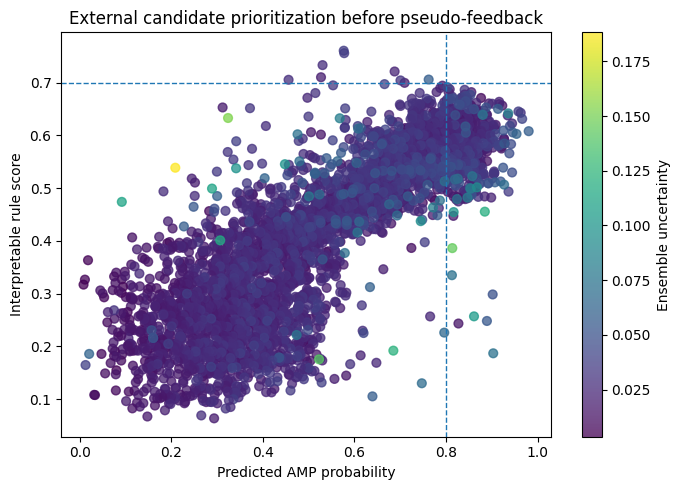

Saved: ../outputs_dtl_cycle/figures/external_prioritization_probability_rule_uncertainty.png


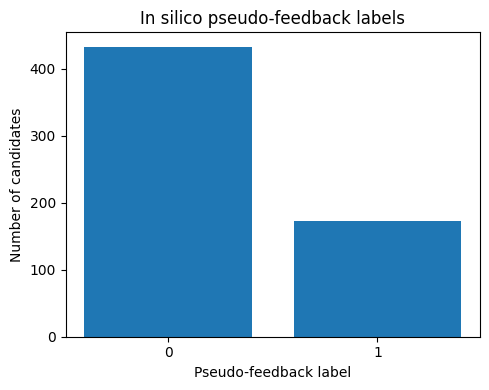

Saved: ../outputs_dtl_cycle/figures/pseudo_feedback_label_distribution.png


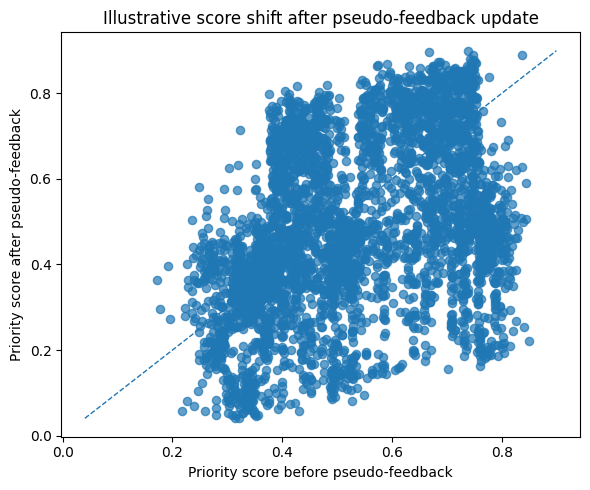

Saved: ../outputs_dtl_cycle/figures/priority_score_shift_after_pseudo_feedback.png


In [14]:
# ============================================================
# 14. Visualizations
# ============================================================

# Figure 1: rule-aware external screening map
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    external_ranked_df["probability_amp_ensemble"],
    external_ranked_df["soft_rule_score"],
    c=external_ranked_df["uncertainty_std"],
    s=40,
    alpha=0.75,
)
plt.axvline(HIGH_PROBABILITY_CUTOFF, linestyle="--", linewidth=1)
plt.axhline(HIGH_RULE_SCORE_CUTOFF, linestyle="--", linewidth=1)
plt.xlabel("Predicted AMP probability")
plt.ylabel("Interpretable rule score")
plt.title("External candidate prioritization before pseudo-feedback")
cbar = plt.colorbar(scatter)
cbar.set_label("Ensemble uncertainty")
plt.tight_layout()
fig_path = FIGURE_DIR / "external_prioritization_probability_rule_uncertainty.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

# Figure 2: pseudo-feedback label distribution
if not pseudo_feedback_df.empty:
    plt.figure(figsize=(5, 4))
    counts = pseudo_feedback_df["pseudo_feedback_label"].value_counts().sort_index()
    plt.bar([str(i) for i in counts.index], counts.values)
    plt.xlabel("Pseudo-feedback label")
    plt.ylabel("Number of candidates")
    plt.title("In silico pseudo-feedback labels")
    plt.tight_layout()
    fig_path = FIGURE_DIR / "pseudo_feedback_label_distribution.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

# Figure 3: pre/post priority score comparison if an update was performed
if "post_feedback_rule_aware_priority_score" in post_feedback_ranked_df.columns and post_feedback_ranked_df["post_feedback_rule_aware_priority_score"].notna().any():
    plt.figure(figsize=(6, 5))
    plt.scatter(
        post_feedback_ranked_df["rule_aware_priority_score"],
        post_feedback_ranked_df["post_feedback_rule_aware_priority_score"],
        alpha=0.7,
        s=35,
    )
    min_score = min(
        post_feedback_ranked_df["rule_aware_priority_score"].min(),
        post_feedback_ranked_df["post_feedback_rule_aware_priority_score"].min(),
    )
    max_score = max(
        post_feedback_ranked_df["rule_aware_priority_score"].max(),
        post_feedback_ranked_df["post_feedback_rule_aware_priority_score"].max(),
    )
    plt.plot([min_score, max_score], [min_score, max_score], linestyle="--", linewidth=1)
    plt.xlabel("Priority score before pseudo-feedback")
    plt.ylabel("Priority score after pseudo-feedback")
    plt.title("Illustrative score shift after pseudo-feedback update")
    plt.tight_layout()
    fig_path = FIGURE_DIR / "priority_score_shift_after_pseudo_feedback.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

## 13. Export final metadata

In [16]:
# ============================================================
# 15. Export metadata and final artefact list
# ============================================================

metadata = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "notebook": "06_external_screening_and_illustrative_dtl_loop_fasta_only",
    "candidate_source": candidate_source,
    "training_metadata_path": str(TRAINING_METADATA_PATH),
    "best_model_selection_path": str(BEST_MODEL_SELECTION_PATH),
    "best_model_name": BEST_MODEL_NAME,
    "ensemble_model_path": str(ensemble_model_path),
    "rulebook_path": str(RULEBOOK_PATH),
    "n_raw_external_candidates": int(initial_n),
    "n_external_candidates_after_filtering": int(len(external_ranked_df)),
    "n_pseudo_feedback_candidates": int(len(pseudo_feedback_df)),
    "pseudo_feedback_thresholds": {
        "positive_probability_cutoff": PSEUDO_POSITIVE_PROBABILITY_CUTOFF,
        "negative_probability_cutoff": PSEUDO_NEGATIVE_PROBABILITY_CUTOFF,
        "high_rule_score_cutoff": PSEUDO_HIGH_RULE_SCORE_CUTOFF,
        "low_rule_score_cutoff": PSEUDO_LOW_RULE_SCORE_CUTOFF,
        "low_uncertainty_cutoff_quantile_25": LOW_UNCERTAINTY_QUANTILE,
        "min_pseudo_per_class_for_update": MIN_PSEUDO_PER_CLASS_FOR_UPDATE,
    },
    "priority_score_formula": "0.55 * P(AMP) + 0.30 * soft_rule_score + 0.15 * confidence_score",
    "updated_model_performed": bool(len(updated_ensemble) > 0) if 'updated_ensemble' in globals() else False,
    "important_note": (
        "Pseudo-feedback labels are in silico model-supported labels and must not be interpreted "
        "as experimental validation. This notebook demonstrates operational design-test-learn logic."
    ),
    "outputs": {
        "uniprot_raw_candidates": str(CANDIDATE_DIR / "uniprot_raw_candidates.tsv"),
        "uniprot_query": str(CANDIDATE_DIR / "uniprot_query.txt"),
        "cleaned_external_candidates": str(cleaned_candidates_path),
        "external_descriptors": str(external_descriptor_path),
        "external_ranked_pre_feedback": str(external_ranked_path),
        "post_feedback_ranking": str(post_feedback_path),
        "manuscript_top_external_candidates": str(manuscript_top_external_path),
        "manuscript_dtl_summary": str(dtl_summary_path),
    },
}

metadata_path = OUTPUT_DIR / "dtl_cycle_metadata.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:", metadata_path)
print("\nGenerated artefacts:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print("-", path)


Saved: ../outputs_dtl_cycle/dtl_cycle_metadata.json

Generated artefacts:
- ../outputs_dtl_cycle/candidates/external_candidates_cleaned.csv
- ../outputs_dtl_cycle/dtl_cycle_metadata.json
- ../outputs_dtl_cycle/figures/external_prioritization_probability_rule_uncertainty.png
- ../outputs_dtl_cycle/figures/priority_score_shift_after_pseudo_feedback.png
- ../outputs_dtl_cycle/figures/pseudo_feedback_label_distribution.png
- ../outputs_dtl_cycle/models/updated_pseudo_feedback_cv_ensemble.joblib
- ../outputs_dtl_cycle/tables/augmented_training_set_with_pseudo_feedback.csv
- ../outputs_dtl_cycle/tables/external_candidate_cleaning_summary.csv
- ../outputs_dtl_cycle/tables/external_candidate_ensemble_member_probabilities.csv
- ../outputs_dtl_cycle/tables/external_candidate_nearest_train_distance_summary.csv
- ../outputs_dtl_cycle/tables/external_candidates_ranked_after_pseudo_feedback_update.csv
- ../outputs_dtl_cycle/tables/external_candidates_rule_aware_ranked_pre_feedback.csv
- ../outputs_d